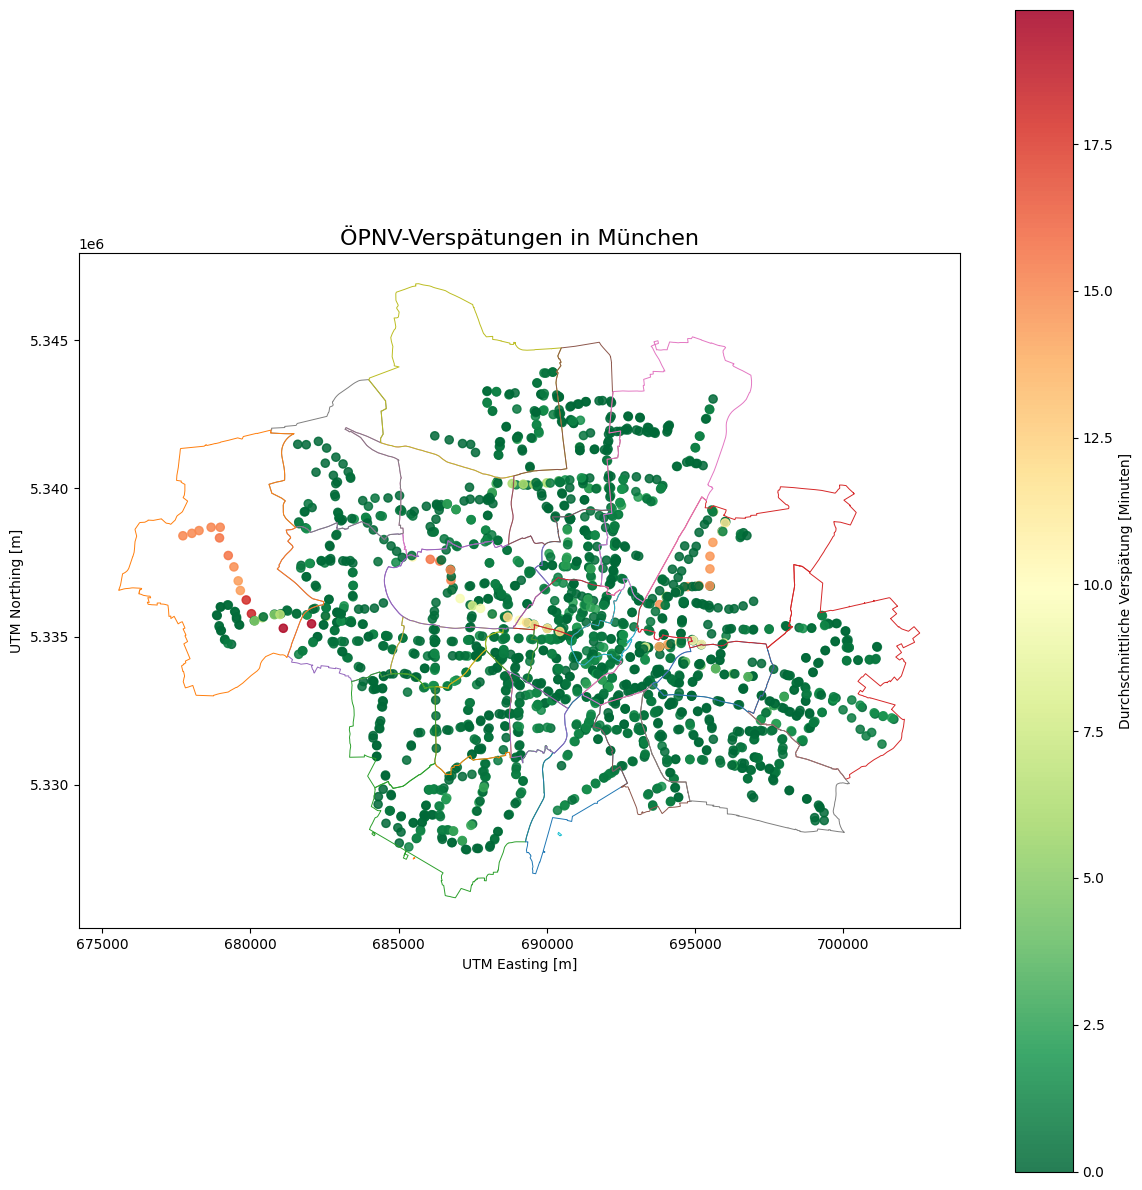

Stationen innerhalb Münchens: 1772


In [34]:
import json
import math
import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# 1. München GeoJSON laden
# ============================================================

with open("../data/munich.geojson", "r") as f:
    munich = json.load(f)


# ============================================================
# 2. WGS84 -> UTM Zone 32N
#    Keine pyproj/geopandas-Abhängigkeit
# ============================================================

def wgs84_to_utm32(lat, lon):

    # WGS84 Ellipsoid
    a = 6378137.0
    ecc_sq = 0.00669437999014
    k0 = 0.9996

    lat_rad = math.radians(lat)
    lon_rad = math.radians(lon)

    # Zentralmeridian von UTM Zone 32
    lon0 = math.radians(9.0)

    ecc_prime_sq = ecc_sq / (1 - ecc_sq)

    N = a / math.sqrt(
        1 - ecc_sq * math.sin(lat_rad) ** 2
    )

    T = math.tan(lat_rad) ** 2

    C = (
        ecc_prime_sq
        * math.cos(lat_rad) ** 2
    )

    A = (
        math.cos(lat_rad)
        * (lon_rad - lon0)
    )

    M = a * (
        (1
         - ecc_sq / 4
         - 3 * ecc_sq**2 / 64
         - 5 * ecc_sq**3 / 256)
        * lat_rad

        - (
            3 * ecc_sq / 8
            + 3 * ecc_sq**2 / 32
            + 45 * ecc_sq**3 / 1024
        )
        * math.sin(2 * lat_rad)

        + (
            15 * ecc_sq**2 / 256
            + 45 * ecc_sq**3 / 1024
        )
        * math.sin(4 * lat_rad)

        - (
            35 * ecc_sq**3 / 3072
        )
        * math.sin(6 * lat_rad)
    )

    easting = k0 * N * (
        A
        + (1 - T + C) * A**3 / 6
        + (
            5
            - 18 * T
            + T**2
            + 72 * C
            - 58 * ecc_prime_sq
        )
        * A**5
        / 120
    ) + 500000.0

    northing = k0 * (
        M
        + N
        * math.tan(lat_rad)
        * (
            A**2 / 2

            + (
                5
                - T
                + 9 * C
                + 4 * C**2
            )
            * A**4
            / 24

            + (
                61
                - 58 * T
                + T**2
                + 600 * C
                - 330 * ecc_prime_sq
            )
            * A**6
            / 720
        )
    )

    return easting, northing


# ============================================================
# 3. Point-in-Polygon
# ============================================================

def point_in_polygon(x, y, polygon):

    inside = False

    n = len(polygon)

    for i in range(n):

        x1, y1 = polygon[i]
        x2, y2 = polygon[(i + 1) % n]

        # Prüfen, ob die horizontale Linie des
        # Punktes die Polygonkante schneidet
        if (y1 > y) != (y2 > y):

            x_intersection = (
                (x2 - x1)
                * (y - y1)
                / (y2 - y1)
                + x1
            )

            if x < x_intersection:
                inside = not inside

    return inside


# ============================================================
# 4. Prüfen, ob Punkt innerhalb München liegt
# ============================================================

def point_in_munich(x, y, geojson):

    for feature in geojson["features"]:

        geometry = feature["geometry"]

        # ----------------------------------------
        # Polygon
        # ----------------------------------------

        if geometry["type"] == "Polygon":

            for ring in geometry["coordinates"]:

                if point_in_polygon(
                    x,
                    y,
                    ring
                ):
                    return True

        # ----------------------------------------
        # MultiPolygon
        # ----------------------------------------

        elif geometry["type"] == "MultiPolygon":

            for polygon in geometry["coordinates"]:

                for ring in polygon:

                    if point_in_polygon(
                        x,
                        y,
                        ring
                    ):
                        return True

    return False


# ============================================================
# 5. Verspätung pro Station berechnen
# ============================================================

station_delay = (
    df
    .dropna(subset=["departure_delay"])
    .groupby(
        ["stop_id", "stop_name"],
        as_index=False
    )["departure_delay"]
    .mean()
)


# GTFS-RT delay ist in Sekunden
station_delay["delay_minutes"] = (
    station_delay["departure_delay"] / 60
)


# Zu frühe Fahrzeuge -> 0 Minuten
station_delay["delay_minutes"] = (
    station_delay["delay_minutes"]
    .clip(lower=0)
)


# ============================================================
# 6. stops.txt laden
# ============================================================

stops = pd.read_csv(
    "../data/stops.txt"
)

stops["stop_id"] = (
    stops["stop_id"]
    .astype(str)
)

stops = stops[
    [
        "stop_id",
        "stop_name",
        "stop_lat",
        "stop_lon"
    ]
]


# ============================================================
# 7. Verspätung + Koordinaten verbinden
# ============================================================

station_delay = station_delay.merge(
    stops,
    on=["stop_id", "stop_name"],
    how="left"
)


# Nur Stationen mit gültigen Koordinaten
station_delay = station_delay.dropna(
    subset=[
        "stop_lat",
        "stop_lon"
    ]
)


# ============================================================
# 8. WGS84 -> UTM 32N
# ============================================================

utm_coordinates = station_delay.apply(
    lambda row: wgs84_to_utm32(
        row["stop_lat"],
        row["stop_lon"]
    ),
    axis=1
)

station_delay["utm_x"] = (
    utm_coordinates.apply(
        lambda x: x[0]
    )
)

station_delay["utm_y"] = (
    utm_coordinates.apply(
        lambda x: x[1]
    )
)


# ============================================================
# 9. Nur Stationen innerhalb Münchens behalten
# ============================================================

station_delay["inside_munich"] = station_delay.apply(
    lambda row: point_in_munich(
        row["utm_x"],
        row["utm_y"],
        munich
    ),
    axis=1
)

station_delay = station_delay[
    station_delay["inside_munich"]
].copy()


# ============================================================
# 10. Karte erstellen
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 12)
)


# ============================================================
# 11. München-Stadtbezirke zeichnen
# ============================================================

for feature in munich["features"]:

    geometry = feature["geometry"]

    if geometry["type"] == "Polygon":

        polygons = [
            geometry["coordinates"]
        ]

    elif geometry["type"] == "MultiPolygon":

        polygons = geometry["coordinates"]

    else:
        continue

    for polygon in polygons:

        for ring in polygon:

            xs = [
                point[0]
                for point in ring
            ]

            ys = [
                point[1]
                for point in ring
            ]

            ax.plot(
                xs,
                ys,
                linewidth=0.7
            )


# ============================================================
# 12. Stationen zeichnen
# ============================================================

scatter = ax.scatter(
    station_delay["utm_x"],
    station_delay["utm_y"],
    c=station_delay["delay_minutes"],
    cmap="RdYlGn_r",
    s=35,
    alpha=0.85
)


# ============================================================
# 13. Colorbar
# ============================================================

cbar = plt.colorbar(
    scatter,
    ax=ax
)

cbar.set_label(
    "Durchschnittliche Verspätung [Minuten]"
)


# ============================================================
# 14. Beschriftungen
# ============================================================

ax.set_title(
    "ÖPNV-Verspätungen in München",
    fontsize=16
)

ax.set_xlabel(
    "UTM Easting [m]"
)

ax.set_ylabel(
    "UTM Northing [m]"
)

ax.set_aspect("equal")


# ============================================================
# 15. Anzeigen
# ============================================================

plt.tight_layout()

plt.savefig(
    "../docs/munich_delays.png",
    dpi=100,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 16. Kontrolle
# ============================================================

print(
    f"Stationen innerhalb Münchens: {len(station_delay)}"
)